# 질문 (Question) 분석


- 질문 길이 분포 (토큰/문자 단위)
- 질문 유형 분석 ("what", "when", "why", "how" 등)
- 중복 질문 존재 여부 
- 질문이 어떤 주제를 많이 다루는지 (예:TF-IDF 기반 클러스터링)


In [10]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import nltk
from tqdm import tqdm
from collections import Counter

In [11]:
print("데이터 로드 중...")

train_dataset = load_from_disk("../../data/train_dataset")
test_dataset = load_from_disk("../../data/test_dataset")

print(train_dataset)
print(test_dataset)

train_df = train_dataset["train"].to_pandas()
val_df = train_dataset["validation"].to_pandas()

print(f"Train 개수: {len(train_df)}, Validation 개수: {len(val_df)}")
print(train_df.head())

데이터 로드 중...
DatasetDict({
    train: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 3952
    })
    validation: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 240
    })
})
DatasetDict({
    validation: Dataset({
        features: ['question', 'id'],
        num_rows: 600
    })
})
Train 개수: 3952, Validation 개수: 240
     title                                            context  \
0    미국 상원  미국 상의원 또는 미국 상원(United States Senate)은 양원제인 미국...   
1   인사조직관리  '근대적 경영학' 또는 '고전적 경영학'에서 현대적 경영학으로 전환되는 시기는 19...   
2      강희제  강희제는 강화된 황권으로 거의 황제 중심의 독단적으로 나라를 이끌어 갔기에 자칫 전...   
3   금동삼존불감  불상을 모시기 위해 나무나 돌, 쇠 등을 깎아 일반적인 건축물보다 작은 규모로 만든...   
4  계사명 사리구  동아대학교박물관에서 소장하고 있는 계사명 사리구는 총 4개의 용기로 구성된 조선후기...   

                                  question            id  \
0         대통령을 포함한 미국의 행정부 견제권을 갖는 국가 기관은?  mrc-1-000067   

## 질문 길이 분포 - train, validation 데이터의 question 길이 분포

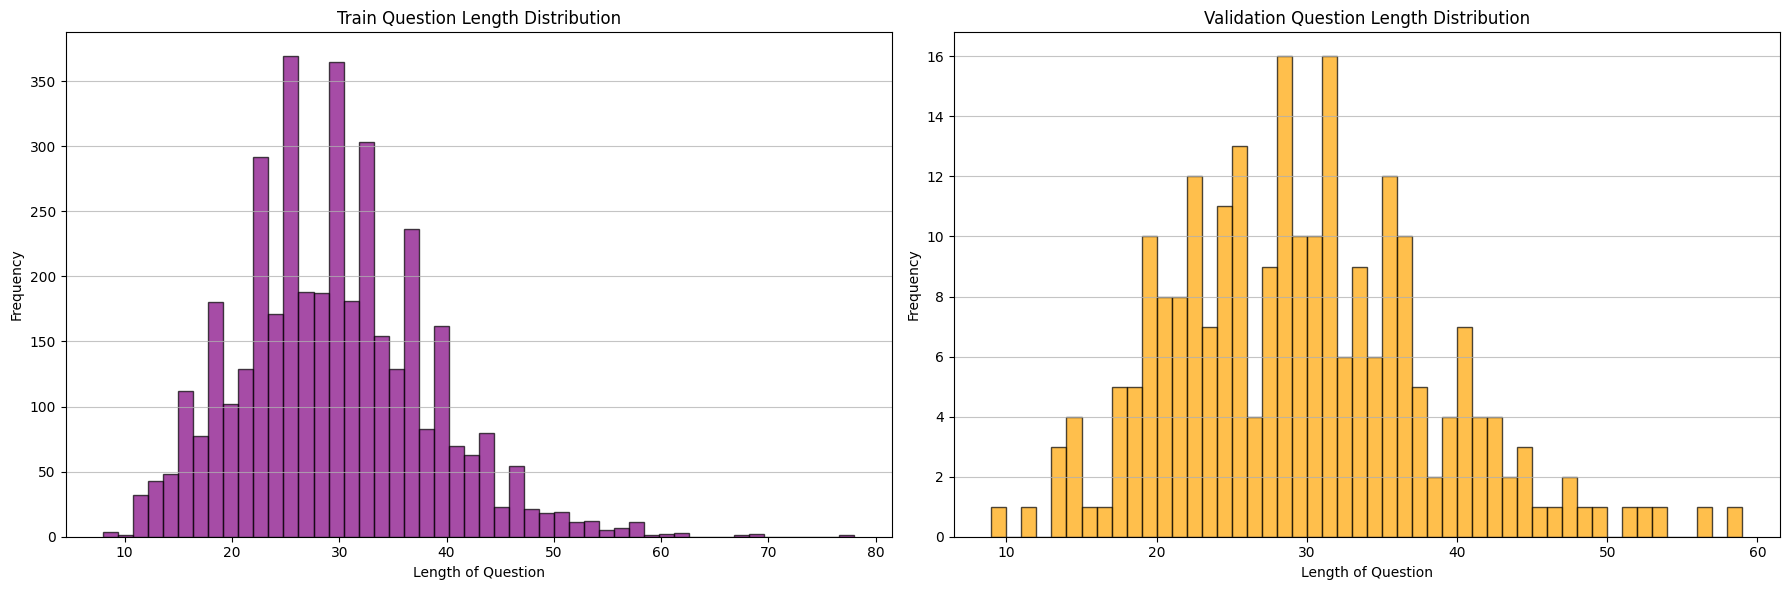

In [19]:
plt.figure(figsize=(18, 6))

# Train question 길이 분포
plt.subplot(1, 2, 1)
plt.hist(train_df['question'].apply(len), bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.title('Train Question Length Distribution')
plt.xlabel('Length of Question')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Validation question 길이 분포
plt.subplot(1, 2, 2)
plt.hist(val_df['question'].apply(len), bins=50, color='orange', edgecolor='black', alpha=0.7)
plt.title('Validation Question Length Distribution')
plt.xlabel('Length of Question')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## 질문 유형 분석

/data/ephemeral/git/pro-nlp-mrc-nlp-01/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/ephemeral/git/pro-nlp-mrc-nlp-01/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/ephemeral/git/pro-nlp-mrc-nlp-01/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/ephemeral/git/pro-nlp-mrc-nlp-01/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/ephemeral/git/pro-nlp-mrc-nlp-01/.venv/lib/python3.10/site-p

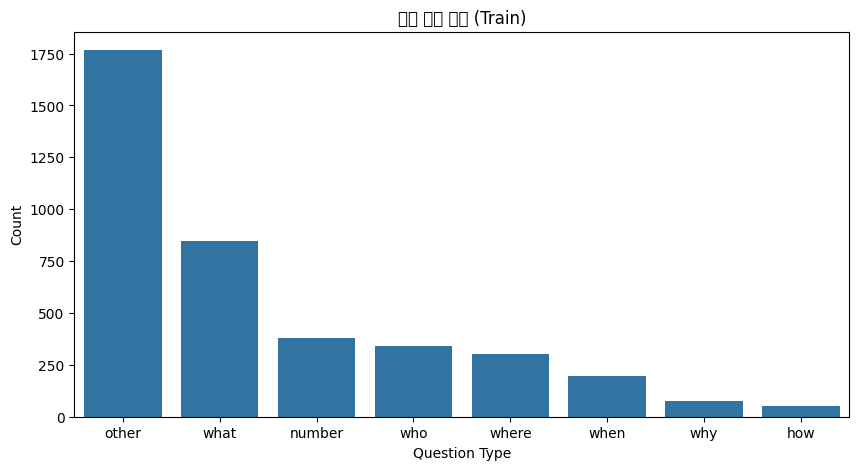

In [20]:
import re

def classify_korean_question(q):
    q = q.strip()
    
    # 정규표현식 기반 의문사 분류
    if re.search(r"누가|누구|누구의", q):
        return "who"
    elif re.search(r"어디|장소|지역", q):
        return "where"
    elif re.search(r"언제|시기|시점", q):
        return "when"
    elif re.search(r"왜|이유|목적", q):
        return "why"
    elif re.search(r"어떻게|방식|방법", q):
        return "how"
    elif re.search(r"무엇|무슨|어떤|것은|이름", q):
        return "what"
    elif re.search(r"몇|숫자|수|년도", q):
        return "number"
    else:
        return "other"

# 적용
train_df["q_type"] = train_df["question"].apply(classify_korean_question)
val_df["q_type"] = val_df["question"].apply(classify_korean_question)

# 분포 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=train_df, x="q_type", order=train_df["q_type"].value_counts().index)
plt.title("질문 유형 분포 (Train)")
plt.xlabel("Question Type")
plt.ylabel("Count")
plt.show()


## 중복 질문 존재 여부

In [21]:
# train과 validation 각각 확인
dup_train = train_df[train_df["question"].duplicated(keep=False)]
dup_val = val_df[val_df["question"].duplicated(keep=False)]

print(f"[Train] 중복된 질문 수: {dup_train['question'].nunique()}개")
print(f"[Validation] 중복된 질문 수: {dup_val['question'].nunique()}개")

# 중복 질문 예시 출력
print("\n[Train 중복 예시]")
display(dup_train[["question", "context", "answers"]].head(5))

print("\n[Validation 중복 예시]")
display(dup_val[["question", "context", "answers"]].head(5))


[Train] 중복된 질문 수: 0개
[Validation] 중복된 질문 수: 0개

[Train 중복 예시]


,question,context,answers



[Validation 중복 예시]


,question,context,answers


##  질문이 어떤 주제를 많이 다루는지 (예:TF-IDF 기반 클러스터링)

In [22]:
from konlpy.tag import Okt
import pandas as pd

okt = Okt()

def preprocess_korean(text):
    # 명사만 추출 (또는 okt.morphs 사용 가능)
    tokens = okt.nouns(text)
    return " ".join(tokens)

train_df["clean_question"] = train_df["question"].apply(preprocess_korean)
val_df["clean_question"] = val_df["question"].apply(preprocess_korean)


ModuleNotFoundError: No module named 'konlpy'